# Overfitting single intervals

## imports

In [7]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from figutils import (
    cm,
    set_figure_style, 
)

set_figure_style()

OUTPUT_DIR = os.path.join("pdfs","overfitting_single")
os.makedirs(OUTPUT_DIR, exist_ok=True)

## data

In [2]:
# paths

ROOT = ".."
OUTPUT_DIR = os.path.join(ROOT,"results/finetuning/alphagenome_pytorch/overfitting/single")

logs_file = os.path.join(OUTPUT_DIR, "summary", "epoch_logs.parquet")

In [80]:
# loads

logs = pd.read_parquet(logs_file)

## figures

In [81]:
logs.value_counts(["density","run_name"])

density  run_name                       
high     original__all                      50
         original__rna_seq_only             50
         original__splice_site_only         50
         original__splice_usage_only        50
         original__splice_junctions_only    50
medium   original__all                      50
         original__rna_seq_only             50
         original__splice_site_only         50
         original__splice_usage_only        50
         original__splice_junctions_only    50
low      original__all                      50
         original__rna_seq_only             50
         original__splice_site_only         50
         original__splice_usage_only        50
         original__splice_junctions_only    50
Name: count, dtype: int64

### splicing heads cannot overfit a single interval

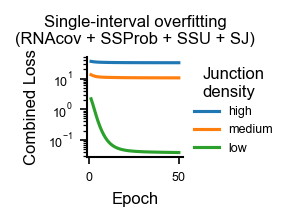

In [ ]:
X = logs.query("run_name=='original__all'")

# combined loss

g = sns.relplot(
    kind="line",
    data=X,
    x="epoch",
    y="train_loss",
    hue="density",
    facet_kws=dict(sharey=False),
    height=3*cm, aspect=1.1
)

g.set(
    xlabel="Epoch",
    ylabel="Combined Loss",
    yscale="log",
    title="Single-interval overfitting\n(RNAcov + SSProb + SSU + SJ)"
)
g.legend.set_title("Junction\ndensity")

plt.show()

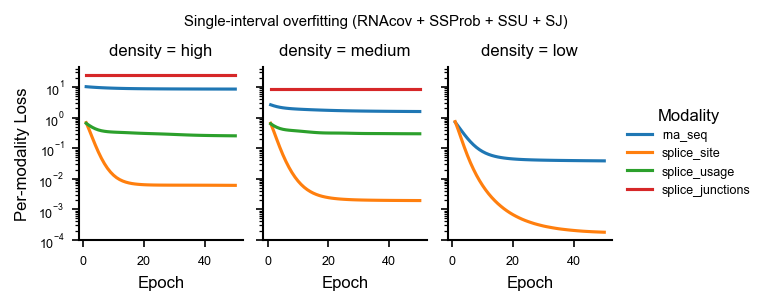

In [76]:
x = (
    X[
        ["epoch","density","val_loss_rna_seq_loss","val_loss_splice_site_loss","val_loss_splice_usage_loss","val_loss_splice_junctions_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="modality",
    col="density",
    facet_kws=dict(sharey=True),
    height=5*cm, aspect=0.7
)

g.set(
    xlabel="Epoch",
    ylabel="Per-modality Loss",
    yscale="log",
)
g.legend.set_title("Modality")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (RNAcov + SSProb + SSU + SJ)")

plt.show()